# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

In [5]:
# frank1d
import frank
from frank.geometry import  SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

## Functions

In [6]:
from matplotlib.ticker import FuncFormatter

def sci_notation(x, pos):
    s = f"{x:.0e}"
    mantissa, exp = s.split('e')
    exp = int(exp)
    return rf"{mantissa}×10$^{{{exp}}}$" 

def float_notation(x, pos):
    s = f"{x:.0f}"
    return s

In [7]:
def calculate_resolution( clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [8]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [9]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

## Load data

In [10]:
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}

In [11]:
data = Elias27

# UVtable
dir = "../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [12]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [13]:
N = 4000

In [14]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [15]:
frank2d = Frank2D(N, rout)

In [16]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [17]:
best = params_N80 = {'m': -2.0397167285521345, 'c': 33723204.88832001, 'l': 34841.2089126212}

## Frank2D

In [18]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [71]:
q_min_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[1]
q_max_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[-1]

In [72]:
start_time = time.time()

frank2d.fit(kernel_params = best_N50, precond_type = 'jacobi', rtol = 1e-8, run_from_scratch=True )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {N} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.2974334115230772, 'c': 316125239602758.7, 'l': 44039.627767028585}
===>  Creating sparse linear system...


        +  Kernel = 0.15  min |  8.92 seconds
        +  Building system = 0.15  min |  9.23 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  5.69e+07  versus  5.69e-01
      .... iteration  10 :   actual tol  2.79e+06  versus  5.69e-01
      .... iteration  20 :   actual tol  2.39e+06  versus  5.69e-01
      .... iteration  30 :   actual tol  2.25e+07  versus  5.69e-01
      .... iteration  40 :   actual tol  2.30e+06  versus  5.69e-01
      .... iteration  50 :   actual tol  4.27e+06  versus  5.69e-01
      .... iteration  60 :   actual tol  7.06e+05  versus  5.69e-01
      .... iteration  70 :   actual tol  1.68e+05  versus  5.69e-01
      .... iteration  80 :   actual tol  3.07e+04  versus  5.69e-01
      .... iteration  90 :   actual tol  4.74e+04  versus  5.69e-01
      .... iteration  100 :   actual tol  5.22e+04  versus  5.69e-01
      .... iteration  110 :   actual tol  3.89e+04  versus  5.69e-01
      .... iteration  120 :   actual tol  1.07e+05 

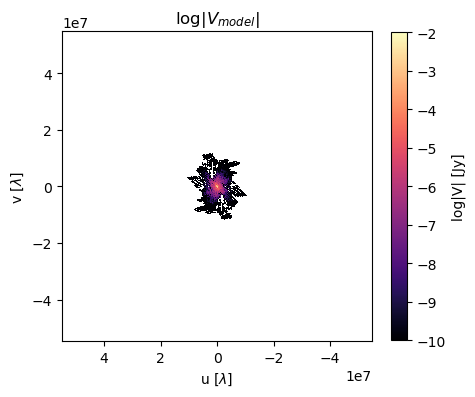

In [75]:
Plot(frank2d, geom_f2d).visibility(kind='model', fig_size = 5, title = r'log|$V_{model}$|')

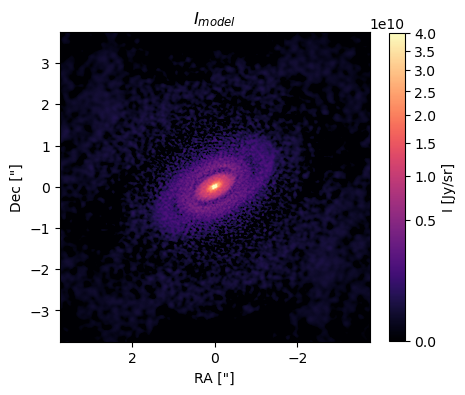

In [77]:
Plot(frank2d, geom_f2d).intensity(fig_size = 5, title = r'$I_{model}$')

## Frank1D

In [19]:
u_f1d, v_f1d =  uvtable['u'], uvtable['v']
vis_f1d = uvtable['vis']
weights_f1d = uvtable['weights']

In [20]:
# Frank 1D parameters
n_pts = 1500
alpha = 1.25
w_smooth = 1e-1
r_out = rout

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, vis_f1d, weights_f1d)


In [ ]:
#save object
import pickle
path_f1d = dir +"f1d_"+ disc+ "_N1500_a1p25_w1em1_r3p76.pkl"
with open(path_f1d, "wb") as file:
    pickle.dump(sol_f1d, file)

In [ ]:

import pickle

path_f1d = dir +"f1d_"+ disc+ "_N1500_a1p25_w1em1_r3p76.pkl"

# Abrir y cargar el objeto
with open(path_f1d, 'rb') as f:   # 'rb' = read binary
    f1d = pickle.load(f)

## CLEAN MODEL

In [23]:

dir_  = "../../data/"
disk_name = data['disk_name']
data_file = dir_ +"CLEAN_model_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u_c, v_c, Re_c, Im_c, Weights_c = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis_c = Re_c + Im_c*1j

In [78]:
# clean model
u_model_c = u_c
v_model_c = v_c
vis_model_c = Vis_c
weights_model_c = Weights_c

In [79]:
uvtable_clean = {'u': u_model_c, 'v': v_model_c, 'vis': vis_model_c, 'weights': weights_model_c}

# Vis space


## 1D
* We use the full uvtable to make the profile.
* There is no convolution here!


In [80]:
f2d = frank2d
geom = geom_f2d

In [81]:
u_input = uvtable['u']
v_input = uvtable['v']
vis_input = uvtable['vis']
weights_input = uvtable['weights']

u_model_1d_f2d = f2d.u
v_model_1d_f2d = f2d.v

In [82]:
# f2d model
u_model_f2d = f2d.u_grid
v_model_f2d = f2d.v_grid
vis_model_f2d = f2d.visibility_model

# phase_shift
# is necessary to be done in the East of North convention.
vis_input = geom.apply_phase_shift(-u_input, -v_input, vis_input)
vis_model_f2d = geom.apply_phase_shift(-u_model_f2d, -v_model_f2d, vis_model_f2d)
vis_model_c = geom.apply_phase_shift(-u_model_c, -v_model_c, vis_model_c)
    
# deproject
u_model_f2d, v_model_f2d, _ = geom.deproject(u_model_f2d, v_model_f2d)
u_model_1d_f2d, v_model_1d_f2d, _ = geom.deproject(u_model_1d_f2d, v_model_1d_f2d)
u_input, v_input, _ = geom.deproject(u_input, v_input)
u_model_c, v_model_c, _ = geom.deproject(u_model_c, v_model_c)


# collocation points for the plot.
q = np.unique(np.hypot(u_model_1d_f2d, v_model_1d_f2d))
q = np.sort(q)
bins = 2*N
q = np.linspace(q[0], q[-1], bins)
edges_ = edges(q)           

In [83]:
#vis_model_f1d = f1d.predict_deprojected(q = q)

In [84]:
bins

8000

In [85]:
np.hypot(u_model_c, v_model_c)/1e4

array([ 52.6995759 ,  29.86200497,   9.68723712, ..., 252.53656881,
       213.37651309, 241.49655609])

In [86]:
# ----------------
baselines = np.hypot(u_input, v_input)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                            np.log10(max(baselines.max(), baselines[-1])),
                            10**4)

bin_widths = [1e3, 5e4, 1e5]

binned_vis0 = UVDataBinner(baselines, vis_input, weights_input , bin_widths[0])
binned_vis1 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[1])
binned_vis2 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[2])


# ----------------
                         

In [87]:
q_model_1d_f2d, vis_model_1d_f2d = get_profile(u_model_f2d, v_model_f2d, vis_model_f2d,
                                            bins = edges_,
                                            weighted = False, weights = frank2d.gridded_data['weights'])

#vis_model_1d_f2d = np.nan_to_num(vis_model_1d_f2d, nan=0)


In [88]:

q_model_1d_c, vis_model_1d_c = get_profile(u_model_c, v_model_c, vis_model_c,
                                                bins = edges_,
                                                weighted = False, weights = weights_model_c)

#vis_model_1d_c = np.nan_to_num(vis_model_1d_c, nan=0)

In [89]:
q_model_1d_data, vis_model_1d_data = get_profile(u_input, v_input, vis_input,
                                                bins = edges_,
                                                weighted = False, weights = weights_input)

In [90]:
cs = ['#c9cad9', 'black']
ms =  ['o', 'x', '.']

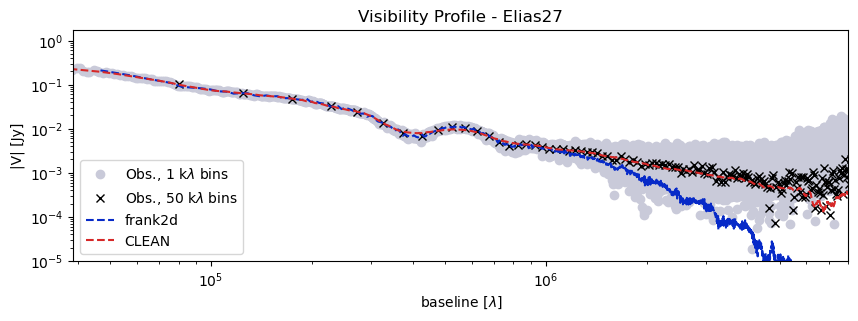

In [91]:
plt.figure(figsize=(10,3))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, np.abs(binned_vis1.V), c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(binned_vis2.uv, np.abs(binned_vis2.V), c='green',
#                marker=ms[2], ls='None', 
#                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[2]/1e3))

# frank2D -------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_f2d), color = '#072ac8', ls ='--', label = r'frank2d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_c), color = '#d62828', ls ='--', label = r'CLEAN')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 0)
plt.xlim(q_min_f2d, 8e6)
plt.title(f'Visibility Profile - {disk_name}')
plt.ylabel('|V| [Jy]', size = 10)
plt.legend(fontsize= 10, loc = 'best')
plt.show()

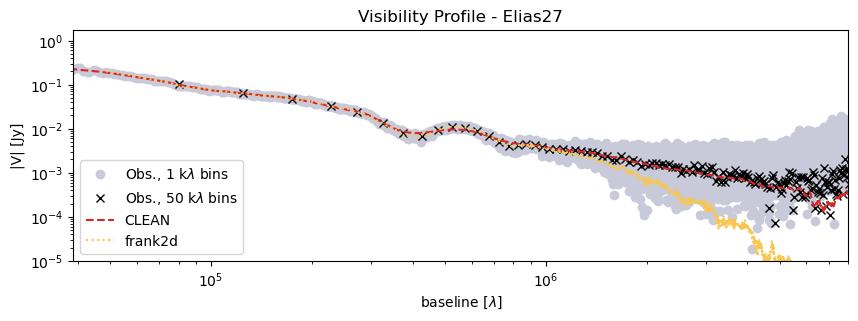

In [99]:
plt.figure(figsize=(10,3))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, np.abs(binned_vis1.V), c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(binned_vis2.uv, np.abs(binned_vis2.V), c='green',
#                marker=ms[2], ls='None', 
#                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[2]/1e3))

# frank1d ---------------------------------------------------------------------
#plt.plot(q, np.abs(vis_model_f1d), color = 'blue', ls ='-', label = r'frank1d')


# CLEAN ---------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_c), color = '#d62828', ls ='--', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_f2d), color = '#f9c74f', ls =':', label = r'frank2d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 0)
plt.xlim(q_min_f2d, 8e6)
plt.title(f'Visibility Profile - {disk_name}')
plt.ylabel('|V| [Jy]', size = 10)
plt.legend(fontsize= 10, loc = 'best')
plt.show()

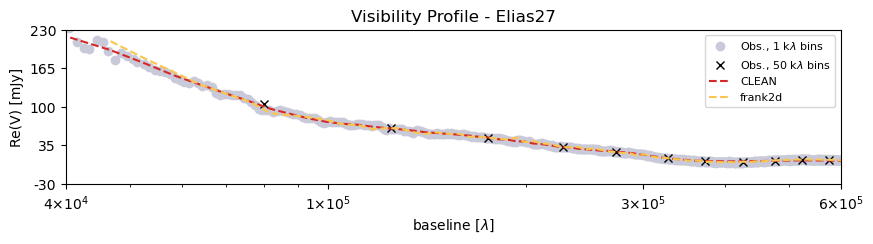

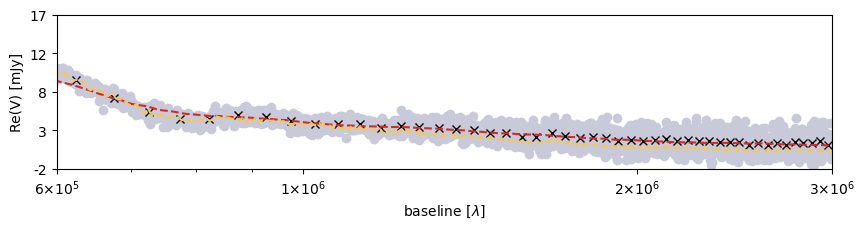

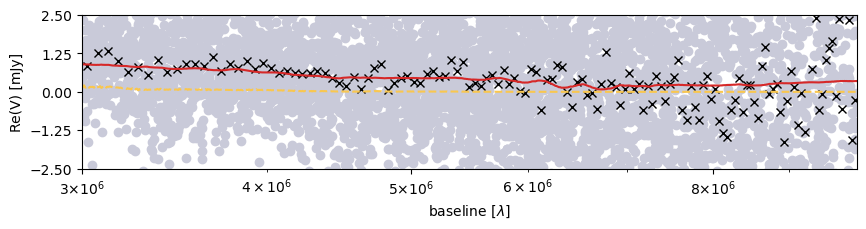

In [100]:
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real*1e3, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

# frank1d ---------------------------------------------------------------------
#plt.plot(q, vis_model_f1d.real*1e3, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real*1e3, color = '#d62828', ls ='--', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real*1e3, color = '#f9c74f', ls ='--', label = r'frank2d')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
y_lim_1 = (-30, 230)
x_lim_1 = (4e4, 6e5)
plt.ylim(y_lim_1)
plt.xlim(x_lim_1)
plt.ylabel('Re(V) [mJy]', size = 10)
plt.title(f'Visibility Profile - {disk_name}')
plt.legend(fontsize = 8, loc = 'best')


plt.xticks([4e4, 1e5, 3e5, 6e5])
plt.yticks(np.linspace(y_lim_1[0], y_lim_1[1], 5))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.yaxis.set_major_formatter(FuncFormatter(float_notation))

plt.show()

plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real*1e3, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
#plt.plot(q, vis_model_f1d.real*1e3, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real*1e3, color = '#d62828', ls ='--', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real*1e3, color = '#f9c74f', ls ='--', label = r'frank2d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
y_lim_2 = (-2, 17)
plt.ylim(y_lim_2)
x_lim_2 = (6e5, 3e6)
plt.xlim(x_lim_2)
plt.ylabel('Re(V) [mJy]', size = 10)
#plt.legend(fontsize = 6, loc = 'best')


plt.xticks([6e5, 1e6, 2e6, 3e6])
plt.yticks(np.linspace(y_lim_2[0], y_lim_2[1], 5))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.yaxis.set_major_formatter(FuncFormatter(float_notation))

plt.show()


plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real*1e3, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
#plt.plot(q, vis_model_f1d.real*1e3, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real*1e3, color = '#d62828', ls ='-', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real*1e3, color = '#f9c74f', ls ='--', label = r'frank2d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
y_lim_3 = (-2.5,2.5)
x_lim_3 = (3e6, 1e7)
plt.ylim(y_lim_3)
plt.xlim(x_lim_3)
plt.ylabel('Re(V) [mJy]', size = 10)
#plt.legend(fontsize = 6, loc = 'best')

plt.xticks([3e6, 5e6, 8e6])
plt.yticks(np.linspace(y_lim_3[0], y_lim_3[1], 5))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))

plt.show()


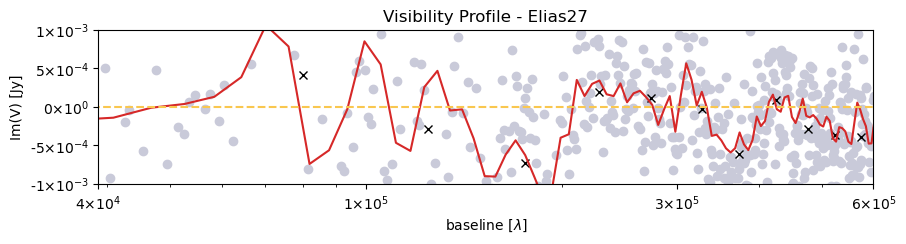

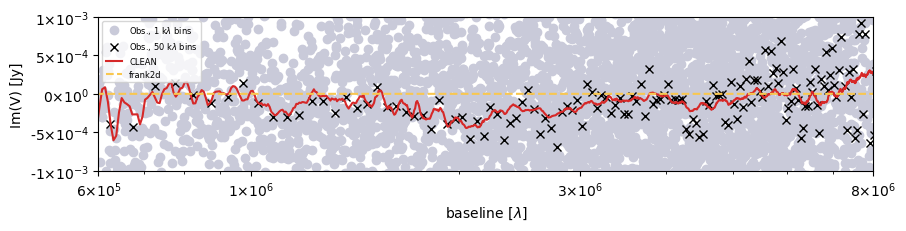

In [101]:
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.imag, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.imag, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
#plt.plot(q, vis_model_f1d.imag, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.imag, color = '#d62828', ls ='-', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.imag, color = '#f9c74f', ls ='--', label = r'frank2d')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.ylim(-0.001, 0.001)
plt.xlim(q_min_f2d, 6e5)
plt.ylabel('Im(V) [Jy]', size = 10)
plt.title(f'Visibility Profile - {disk_name}')
#plt.legend(fontsize = 7, loc = 'best')

plt.xticks([q_min_f2d, 1e5, 3e5, 6e5])
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))


plt.show()



plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.imag, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.imag, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
#plt.plot(q, vis_model_f1d.imag, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.imag, color = '#d62828', ls ='-', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.imag, color = '#f9c74f', ls ='--', label = r'frank2d')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.ylim(-0.001, 0.001)
plt.xlim(6e5, 8e6)
plt.ylabel('Im(V) [Jy]', size = 10)
#plt.title(f'Visibility Profile - {disk_name}')
plt.legend(fontsize = 6, loc = 'best')
plt.xticks([6e5, 1e6, 3e6, 8e6])
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))


plt.show()

In [102]:
residual_f2d_clean = np.abs(vis_model_1d_f2d-vis_model_1d_c)

In [103]:
ground = vis_model_1d_data

In [104]:
residual_clean_data = ground - vis_model_1d_c

In [105]:
residual_f2d_data  =  ground - vis_model_1d_f2d

In [106]:
q_max = 5e6
def rmse(model, ground):
    residuals = model - ground
    # fit until certain baseline
    residuals = residuals[q_model_1d_data <= q_max]
    residuals = residuals[~np.isnan(residuals)]
    rmse_ = np.sqrt(np.mean(residuals**2))
    return rmse_

# RMSE
avg_residual_f2d_data = rmse(vis_model_1d_f2d, ground)
avg_residual_clean_data = rmse(vis_model_1d_c, ground)

In [107]:
avg_residual_f2d_data

(0.0020226675207244307-5.254154371374372e-05j)

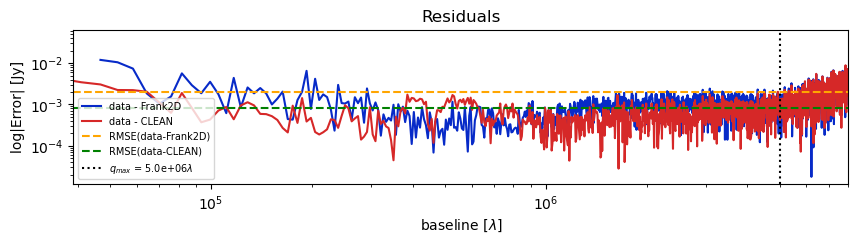

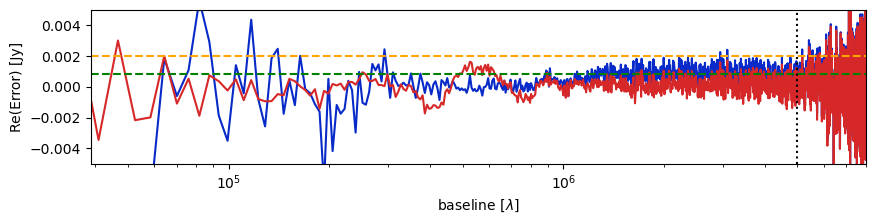

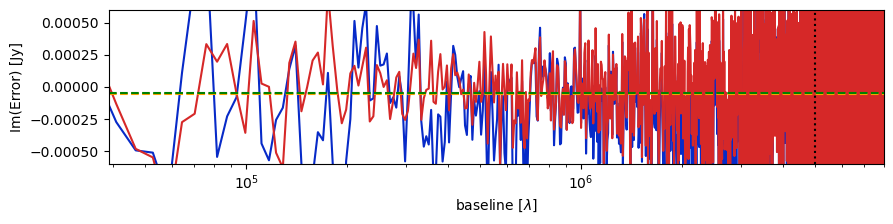

In [108]:
plt.figure(figsize=(10,2))
#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')
plt.plot(q, np.abs(residual_f2d_data), color = '#072ac8', ls ='-', label = r'data - Frank2D')
plt.plot(q, np.abs(residual_clean_data), color = '#d62828', ls ='-', label = r'data - CLEAN')
plt.axhline(np.abs(avg_residual_f2d_data), color = 'orange', ls ='--', label = r'RMSE(data-Frank2D)')
plt.axhline(np.abs(avg_residual_clean_data), color = 'green', ls ='--', label = r'RMSE(data-CLEAN)')
plt.xlabel(r'baseline [$\lambda$]')
plt.axvline(q_max, color = 'black', ls =':', label = r'$q_{max} $ = ' + f'{q_max:.1e}$\lambda$')
plt.axhline(0.0, color = 'gray', ls ='-')
plt.xscale('log')
#plt.ylim(-0.001, 0.01)
plt.yscale('log')
plt.xlim(q_min_f2d, 8e6)
plt.ylabel('log|Error| [Jy]', size = 10)
plt.title('Residuals')
plt.legend(fontsize= 7, loc = 'best')
plt.show()

plt.figure(figsize=(10,2))
#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')
plt.plot(q, residual_f2d_data.real, color = '#072ac8', ls ='-', label = r'data - f2d')
plt.plot(q, residual_clean_data.real, color = '#d62828', ls ='-', label = r'data - CLEAN')
plt.axhline(avg_residual_f2d_data.real, color = 'orange', ls ='--', label = r'RMSE(data-clean)')
plt.axhline(avg_residual_clean_data.real, color = 'green', ls ='--', label = r'RMSE(dar)')
plt.axvline(q_max, color = 'black', ls =':', label = r'$q_{max} $ = ' + f'{q_max:.1e}$\lambda$')
#plt.axhline(0.0, color = 'gray', ls ='-')
plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
#plt.yscale('log')
plt.ylim(-0.005, 0.005)
plt.xlim(q_min_f2d, 8e6)
plt.ylabel('Re(Error) [Jy]', size = 10)
plt.show()

plt.figure(figsize=(10,2))
#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')
plt.plot(q, residual_f2d_data.imag, color = '#072ac8', ls ='-', label = r'f2d-data')
plt.plot(q, residual_clean_data.imag, color = '#d62828', ls ='-', label = r'clean-data')
#plt.axhline(0.0, color = 'gray', ls ='-')
plt.axhline(avg_residual_f2d_data.imag, color = 'orange', ls ='--', label = r'RMSE(f2d-data)')
plt.axhline(avg_residual_clean_data.imag, color = 'green', ls ='--', label = r'RMSE(clean-data)')
plt.xlabel(r'baseline [$\lambda$]')
plt.axvline(q_max, color = 'black', ls =':', label = r'$q_{max} $ = ' + f'{q_max:.1e}$\lambda$')
plt.xscale('log')
#plt.yscale('log')
plt.ylim(-0.0006, 0.0006)
plt.xlim(q_min_f2d, 8e6)
plt.ylabel('Im(Error) [Jy]', size = 10)
plt.show()

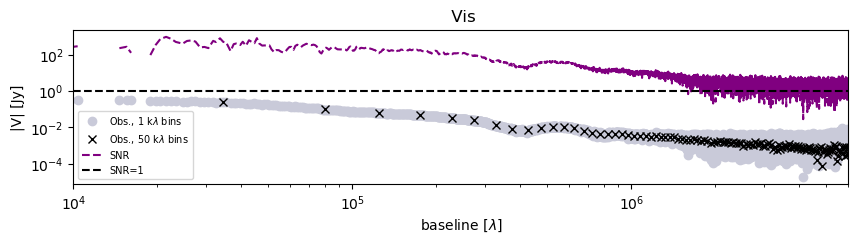

In [109]:
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------
plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, np.abs(binned_vis1.V), c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

# frank2D -------------------------------------------------------------------
sigma = 1/np.sqrt(binned_vis0.weights)
snr =  np.abs(binned_vis0.V)*np.sqrt(binned_vis0.weights)

plt.plot(binned_vis0.uv, snr, color = 'purple', ls ='--', label = r'SNR')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(-0.1, 0.1)
plt.xlim(1e4, 6e6)
plt.axhline(1, color='black', ls='--', label='SNR=1')
plt.ylabel('|V| [Jy]', size = 10)
plt.title(' Vis')
plt.legend(fontsize= 7, loc = 'lower left')
plt.show()

## 2D


* We compare with FFT(CLEAN .model)
* By now, we'll use imsize = 3000, rout = 2,4 -> cellsize = 0.0016, but in the future we plan rout = 2,4 and imsize = 1600 -> REDO CLEAN!

In [113]:
imsize = 4000
rmax = rout

In [114]:
frank2d2 = frank2d

In [115]:
cell =  2*rmax/imsize
cell

0.00188

### Frank2d Vis Map

In [116]:
vis2d_f2d = frank2d2.visibility_model

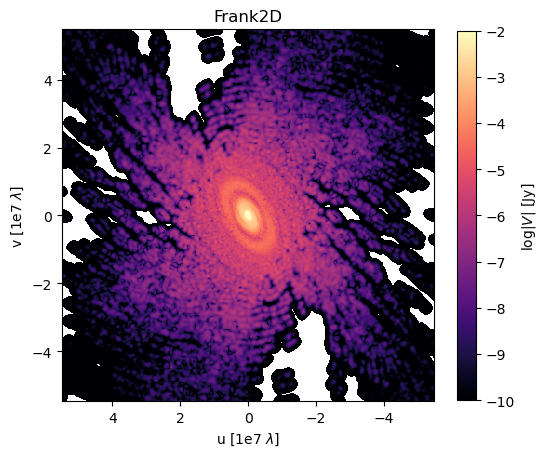

In [155]:
u_f2d, v_f2d = -frank2d2.u_grid.reshape(imsize,imsize), -frank2d2.v_grid.reshape(imsize,imsize)

plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
                np.log(np.abs(vis2d_f2d.reshape(imsize,imsize))),
                cmap="magma",
                vmin=-10, vmax=-2)
plt.xlabel(r'u [1e7 $\lambda$]')
plt.ylabel(r'v [1e7 $\lambda$]')
plt.title("Frank2D")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()

### CLEAN .model

In [118]:
from astropy.io import fits
dir_  = "../../data/"

disk = "Elias27_I_model.fits"

fits_name = dir_ + disk
hdul = fits.open(fits_name)

In [119]:
import matplotlib.colors as colors

In [120]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [121]:
hdr = hdul[0].header
data = hdul[0].data 

In [122]:
# beam
bmaj = hdr.get('BMAJ') # degrees
#bmaj_arsec = bmaj * 3600 # arcseconds
#bmin = hdr.get('BMIN')
#bmin_arsec = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [123]:
w = WCS(hdr)

In [124]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 4000, 4000) -> squeezed: (4000, 4000)


In [125]:
data = data_squeezed

In [126]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [127]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



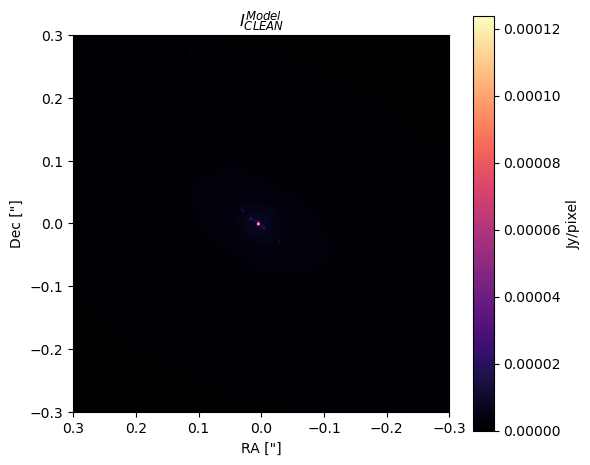

In [128]:
plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=1, vmin=0, vmax = img.max())
ax = plt.gca()
im = ax.imshow(
    img,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title(r'$I^{Model}_{CLEAN}$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(hdr.get('BUNIT', 'Intensity'))
plt.xlim(0.3, -0.3)
plt.ylim(-0.3, 0.3)
ax.grid(False)
plt.tight_layout()
plt.show()

In [129]:
# arcsecs per pixel
ra_off_arcsec[0][1] -ra_off_arcsec[0][0]

-0.0018800154705269634

In [130]:
# img comes without the beam convolutded
# I_clean_model =  np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_model_c_grid))).real/(frank2d3.FT._dx * frank2d3.FT._dy)
vis_clean = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

In [131]:
vis_clean.shape

(4000, 4000)

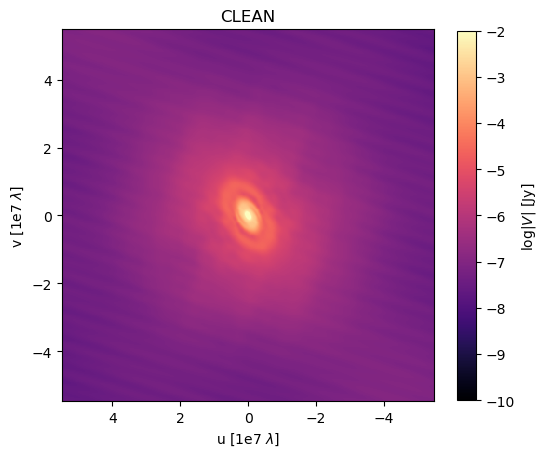

In [154]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
            np.log(np.abs(vis_clean.reshape(imsize, imsize))),
            cmap="magma",
            vmin=-10, vmax=-2)
plt.xlabel(r'u [1e7 $\lambda$]')
plt.ylabel(r'v [1e7 $\lambda$]')
plt.title("CLEAN")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()

### Difference

In [163]:
diff = (vis2d_f2d - vis_clean)

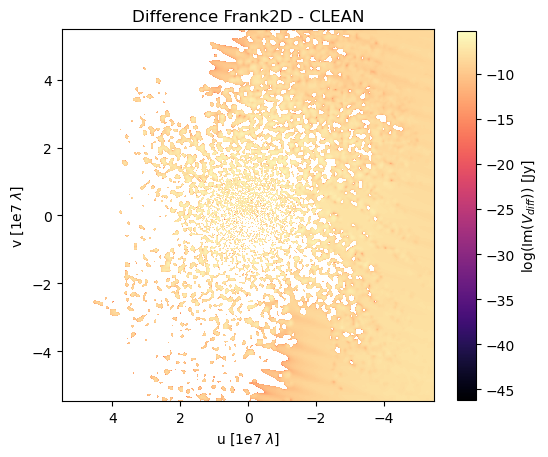

In [180]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
            np.log(diff.imag.reshape(imsize, imsize)),
            cmap="magma")
plt.xlabel(r'u [1e7 $\lambda$]')
plt.ylabel(r'v [1e7 $\lambda$]')
plt.title("Difference Frank2D - CLEAN")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log(Im($V_{diff}$)) [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()